# 问题四：基于 OR-logic 的 NTU 连续风险综合评分

本 notebook 使用原始出厂水浊度 `NTU`，按运行日构造五维风险向量，并用概率和 OR

\[
R=1-\prod_{i=1}^{5}(1-r_i)
\]

计算位于 `[0,1]` 的连续综合风险评分。

本版本**不预设安全、低风险、中风险和高风险的分界阈值**。评分结果与连续蜂群图用于后续人工观察和确定分界。

关键约定：

- 运行日：当天 `07:00` 至次日 `05:00`，理论上 12 个两小时观测点；
- 少于 6 个有效点的运行日保留，但不计算评分；
- 未超标日仍保留波动和连续上升带来的原始 OR 预警分数；
- 缺失日评分为 `NaN`，不会被当作零风险。

## 1. 依赖与参数

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

TARGET_COL = "NTU"
STANDARD_LIMIT = 1.0
WARNING_LEVEL = 0.7
EXPECTED_POINTS_PER_DAY = 12
MIN_VALID_POINTS = 6
EXPECTED_INTERVAL = pd.Timedelta(hours=2)

Q1_START = pd.Timestamp("2026-01-01")
Q1_END = pd.Timestamp("2026-03-31")
MARCH_START = pd.Timestamp("2026-03-01")
MARCH_END = pd.Timestamp("2026-03-31")

RISK_CAPS = {
    "max_excess": 4.0,
    "exceed_ratio": 0.50,
    "median_excess": 0.50,
    "ntu_std": 0.50,
    "longest_rising_steps": 4.0,
}

RAW_INDICATORS = list(RISK_CAPS)
NORMALIZED_INDICATORS = [f"r_{name}" for name in RAW_INDICATORS]

def locate_project_root():
    cwd = Path.cwd().resolve()
    for root in [cwd] + list(cwd.parents):
        if (root / "data" / "merged.xlsx").exists():
            return root
    raise FileNotFoundError("未找到 data/merged.xlsx，请从项目目录或其子目录运行。")

PROJECT_ROOT = locate_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "merged.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "codes" / "p4" / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCEL_PATH = OUTPUT_DIR / "problem4_OR_risk_scores.xlsx"
print("项目目录：", PROJECT_ROOT)
print("数据文件：", DATA_PATH)
print("Excel 输出：", EXCEL_PATH)


项目目录： /Users/jinyu/workspace/2026亚太杯
数据文件： /Users/jinyu/workspace/2026亚太杯/data/merged.xlsx
Excel 输出： /Users/jinyu/workspace/2026亚太杯/codes/p4/outputs/problem4_OR_risk_scores.xlsx


## 2. 读取原始 NTU 并构造运行日

将 `DATE + TIME` 组合为实际时间。凌晨 `01:00、03:00、05:00` 归入前一个运行日，
从而保证一个完整运行日对应 `07:00` 至次日 `05:00`。

In [2]:
raw = pd.read_excel(DATA_PATH)
required_cols = {"DATE", "TIME", TARGET_COL}
missing_cols = required_cols.difference(raw.columns)
if missing_cols:
    raise ValueError(f"缺少必要字段：{sorted(missing_cols)}")

data = raw[["DATE", "TIME", TARGET_COL]].copy()
data["DATE"] = pd.to_datetime(data["DATE"], errors="coerce").dt.normalize()
data["TIME_DELTA"] = pd.to_timedelta(data["TIME"].astype(str).str.strip(), errors="coerce")
data["DATETIME"] = data["DATE"] + data["TIME_DELTA"]
data[TARGET_COL] = pd.to_numeric(data[TARGET_COL], errors="coerce")
data = data.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

data["OP_DATE"] = data["DATETIME"].dt.normalize()
before_seven = data["DATETIME"].dt.hour < 7
data.loc[before_seven, "OP_DATE"] = (
    data.loc[before_seven, "DATETIME"] - pd.Timedelta(days=1)
).dt.normalize()

source_audit = pd.DataFrame({
    "item": [
        "source_rows", "source_datetime_start", "source_datetime_end",
        "operation_date_start", "operation_date_end", "valid_NTU_points",
        "missing_NTU_points", "NTU_above_1_points", "maximum_NTU"
    ],
    "value": [
        len(data), data["DATETIME"].min(), data["DATETIME"].max(),
        data["OP_DATE"].min(), data["OP_DATE"].max(),
        data[TARGET_COL].notna().sum(), data[TARGET_COL].isna().sum(),
        (data[TARGET_COL] > STANDARD_LIMIT).sum(), data[TARGET_COL].max()
    ]
})

display(source_audit)
display(data[["DATETIME", "OP_DATE", TARGET_COL]].head(15))

,item,value
0,source_rows,5460
1,source_datetime_start,2025-01-01 07:00:00
2,source_datetime_end,2026-04-01 05:00:00
3,operation_date_start,2025-01-01 00:00:00
4,operation_date_end,2026-03-31 00:00:00
5,valid_NTU_points,5124
6,missing_NTU_points,336
7,NTU_above_1_points,179
8,maximum_NTU,11.9000


,DATETIME,OP_DATE,NTU
0,2025-01-01 07:00:00,2025-01-01,0.1200
1,2025-01-01 09:00:00,2025-01-01,0.1200
2,2025-01-01 11:00:00,2025-01-01,0.1200
3,2025-01-01 13:00:00,2025-01-01,0.1100
4,2025-01-01 15:00:00,2025-01-01,0.1100
5,2025-01-01 17:00:00,2025-01-01,0.1100
6,2025-01-01 19:00:00,2025-01-01,0.1100
7,2025-01-01 21:00:00,2025-01-01,0.1100
8,2025-01-01 23:00:00,2025-01-01,0.1200
9,2025-01-02 01:00:00,2025-01-01,0.1200


## 3. 五维日风险向量

每日原始指标为：

1. `max_excess`：最大超标幅度；
2. `exceed_ratio`：有效观测点中的超标点占比；
3. `median_excess`：仅在超标点上计算的 `NTU-1` 中位数；
4. `ntu_std`：每日 NTU 总体标准差（`ddof=0`）；
5. `longest_rising_steps`：相邻点均大于 `0.7`、时间差恰为 2 小时且持续上升的最长比较步数。

连续上升遇到缺测、时间缺口、下降或任一点不高于 `0.7` 时立即重置。

In [3]:
def longest_rising_steps(group, warning_level=WARNING_LEVEL):
    ordered = group.sort_values("DATETIME")[["DATETIME", TARGET_COL]]
    times = ordered["DATETIME"].tolist()
    values = ordered[TARGET_COL].tolist()

    best = 0
    current = 0
    for index in range(1, len(ordered)):
        previous_value = values[index - 1]
        current_value = values[index]
        exact_interval = (times[index] - times[index - 1]) == EXPECTED_INTERVAL
        valid_pair = pd.notna(previous_value) and pd.notna(current_value)
        rising_above_warning = (
            valid_pair
            and previous_value > warning_level
            and current_value > warning_level
            and current_value > previous_value
        )
        if exact_interval and rising_above_warning:
            current += 1
            best = max(best, current)
        else:
            current = 0
    return best


def summarize_operation_day(op_date, group):
    valid_values = group[TARGET_COL].dropna()
    n_valid = len(valid_values)
    coverage = n_valid / EXPECTED_POINTS_PER_DAY
    can_score = n_valid >= MIN_VALID_POINTS

    result = {
        "OP_DATE": pd.Timestamp(op_date),
        "n_expected": EXPECTED_POINTS_PER_DAY,
        "n_valid": n_valid,
        "data_coverage": coverage,
        "is_complete_day": n_valid == EXPECTED_POINTS_PER_DAY,
        "can_score": can_score,
        "data_status": (
            "完整可评分" if n_valid == EXPECTED_POINTS_PER_DAY
            else "不完整但可评分" if can_score
            else "有效点不足，不评分"
        ),
    }

    if n_valid == 0:
        result.update({
            "mean_NTU": np.nan, "max_NTU": np.nan, "min_NTU": np.nan,
            "max_excess": np.nan, "exceed_ratio": np.nan,
            "median_excess": np.nan, "ntu_std": np.nan,
            "longest_rising_steps": np.nan,
        })
        return result

    excess = (valid_values - STANDARD_LIMIT).clip(lower=0)
    positive_excess = excess[excess > 0]
    result.update({
        "mean_NTU": valid_values.mean(),
        "max_NTU": valid_values.max(),
        "min_NTU": valid_values.min(),
        "max_excess": excess.max(),
        "exceed_ratio": (valid_values > STANDARD_LIMIT).mean(),
        "median_excess": positive_excess.median() if len(positive_excess) else 0.0,
        "ntu_std": valid_values.std(ddof=0),
        "longest_rising_steps": longest_rising_steps(group),
    })
    return result

In [4]:
observed_daily = pd.DataFrame([
    summarize_operation_day(op_date, group)
    for op_date, group in data.groupby("OP_DATE", sort=True)
])

full_calendar = pd.DataFrame({
    "OP_DATE": pd.date_range(
        observed_daily["OP_DATE"].min(),
        observed_daily["OP_DATE"].max(),
        freq="D"
    )
})
daily = full_calendar.merge(observed_daily, on="OP_DATE", how="left")

no_rows = daily["n_valid"].isna()
daily.loc[no_rows, "n_expected"] = EXPECTED_POINTS_PER_DAY
daily.loc[no_rows, "n_valid"] = 0
daily.loc[no_rows, "data_coverage"] = 0.0
daily.loc[no_rows, "is_complete_day"] = False
daily.loc[no_rows, "can_score"] = False
daily.loc[no_rows, "data_status"] = "无观测记录，不评分"

daily["n_expected"] = daily["n_expected"].astype(int)
daily["n_valid"] = daily["n_valid"].astype(int)
daily["is_complete_day"] = daily["is_complete_day"].astype(bool)
daily["can_score"] = daily["can_score"].astype(bool)

display(daily.head())
print("全历史日历日：", len(daily))
print("可评分运行日：", int(daily["can_score"].sum()))
print("完整运行日：", int(daily["is_complete_day"].sum()))

,OP_DATE,n_expected,n_valid,data_coverage,is_complete_day,can_score,data_status,mean_NTU,max_NTU,min_NTU,max_excess,exceed_ratio,median_excess,ntu_std,longest_rising_steps
0,2025-01-01,12,12,1.0000,True,True,完整可评分,0.1158,0.1200,0.1100,0.0000,0.0000,0.0000,0.0049,0.0000
1,2025-01-02,12,12,1.0000,True,True,完整可评分,0.1183,0.1300,0.1000,0.0000,0.0000,0.0000,0.0099,0.0000
2,2025-01-03,12,12,1.0000,True,True,完整可评分,0.1175,0.1300,0.1100,0.0000,0.0000,0.0000,0.0072,0.0000
3,2025-01-04,12,12,1.0000,True,True,完整可评分,0.1250,0.1500,0.1100,0.0000,0.0000,0.0000,0.0112,0.0000
4,2025-01-05,12,12,1.0000,True,True,完整可评分,0.1200,0.1300,0.1100,0.0000,0.0000,0.0000,0.0071,0.0000


全历史日历日： 455
可评分运行日： 427
完整运行日： 427


## 4. 固定上限归一化与概率和 OR

每项指标按固定风险上限映射并截断：

\[
r_i=\min\left(\frac{x_i}{c_i},1\right)
\]

固定上限依次为 `1.0 NTU、0.50、0.5 NTU、0.5 NTU、4 步`。
只有有效点不少于 6 的运行日计算综合评分。

In [5]:
for indicator, cap in RISK_CAPS.items():
    normalized_col = f"r_{indicator}"
    daily[normalized_col] = np.where(
        daily["can_score"],
        (daily[indicator] / cap).clip(lower=0, upper=1),
        np.nan,
    )

daily["OR_risk_score"] = np.where(
    daily["can_score"],
    1.0 - np.prod(1.0 - daily[NORMALIZED_INDICATORS], axis=1),
    np.nan,
)

score_columns = [
    "OP_DATE", "data_status", "n_expected", "n_valid", "data_coverage",
    "is_complete_day", "can_score", "mean_NTU", "max_NTU", "min_NTU",
    *RAW_INDICATORS, *NORMALIZED_INDICATORS, "OR_risk_score",
]
daily_scores = daily[score_columns].copy()

display(daily_scores.loc[daily_scores["can_score"]].head())
display(daily_scores["OR_risk_score"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
))

,OP_DATE,data_status,n_expected,n_valid,data_coverage,is_complete_day,can_score,mean_NTU,max_NTU,min_NTU,max_excess,exceed_ratio,median_excess,ntu_std,longest_rising_steps,r_max_excess,r_exceed_ratio,r_median_excess,r_ntu_std,r_longest_rising_steps,OR_risk_score
0,2025-01-01,完整可评分,12,12,1.0000,True,True,0.1158,0.1200,0.1100,0.0000,0.0000,0.0000,0.0049,0.0000,0.0000,0.0000,0.0000,0.0099,0.0000,0.0099
1,2025-01-02,完整可评分,12,12,1.0000,True,True,0.1183,0.1300,0.1000,0.0000,0.0000,0.0000,0.0099,0.0000,0.0000,0.0000,0.0000,0.0197,0.0000,0.0197
2,2025-01-03,完整可评分,12,12,1.0000,True,True,0.1175,0.1300,0.1100,0.0000,0.0000,0.0000,0.0072,0.0000,0.0000,0.0000,0.0000,0.0144,0.0000,0.0144
3,2025-01-04,完整可评分,12,12,1.0000,True,True,0.1250,0.1500,0.1100,0.0000,0.0000,0.0000,0.0112,0.0000,0.0000,0.0000,0.0000,0.0224,0.0000,0.0224
4,2025-01-05,完整可评分,12,12,1.0000,True,True,0.1200,0.1300,0.1100,0.0000,0.0000,0.0000,0.0071,0.0000,0.0000,0.0000,0.0000,0.0141,0.0000,0.0141


count   427.0000
mean      0.1580
std       0.2779
min       0.0000
25%       0.0229
50%       0.0382
75%       0.1038
90%       0.5830
95%       1.0000
99%       1.0000
max       1.0000
Name: OR_risk_score, dtype: float64

## 5. 2026 年第一季度与 3 月结果

In [6]:
q1_calendar = pd.DataFrame({"OP_DATE": pd.date_range(Q1_START, Q1_END, freq="D")})
q1 = q1_calendar.merge(daily_scores, on="OP_DATE", how="left")

q1_missing = q1["data_status"].isna()
q1.loc[q1_missing, "data_status"] = "无观测记录，不评分"
q1.loc[q1_missing, "n_expected"] = EXPECTED_POINTS_PER_DAY
q1.loc[q1_missing, "n_valid"] = 0
q1.loc[q1_missing, "data_coverage"] = 0.0
q1.loc[q1_missing, "is_complete_day"] = False
q1.loc[q1_missing, "can_score"] = False

march = q1[q1["OP_DATE"].between(MARCH_START, MARCH_END)].copy()

q1_summary = pd.DataFrame({
    "item": [
        "calendar_days", "scored_days", "unscored_days",
        "complete_days", "partial_scored_days", "score_mean",
        "score_median", "score_max"
    ],
    "value": [
        len(q1), q1["OR_risk_score"].notna().sum(),
        q1["OR_risk_score"].isna().sum(),
        q1["is_complete_day"].fillna(False).sum(),
        ((q1["can_score"] == True) & (q1["is_complete_day"] == False)).sum(),
        q1["OR_risk_score"].mean(), q1["OR_risk_score"].median(),
        q1["OR_risk_score"].max()
    ]
})

display(q1_summary)
display(march)

,item,value
0,calendar_days,90.0000
1,scored_days,62.0000
2,unscored_days,28.0000
3,complete_days,62.0000
4,partial_scored_days,0.0000
5,score_mean,0.1127
6,score_median,0.0304
7,score_max,1.0000


,OP_DATE,data_status,n_expected,n_valid,data_coverage,is_complete_day,can_score,mean_NTU,max_NTU,min_NTU,max_excess,exceed_ratio,median_excess,ntu_std,longest_rising_steps,r_max_excess,r_exceed_ratio,r_median_excess,r_ntu_std,r_longest_rising_steps,OR_risk_score
59,2026-03-01,完整可评分,12,12,1.0000,True,True,0.4525,0.4800,0.4200,0.0000,0.0000,0.0000,0.0159,0.0000,0.0000,0.0000,0.0000,0.0318,0.0000,0.0318
60,2026-03-02,完整可评分,12,12,1.0000,True,True,0.4733,0.4900,0.4500,0.0000,0.0000,0.0000,0.0149,0.0000,0.0000,0.0000,0.0000,0.0298,0.0000,0.0298
61,2026-03-03,完整可评分,12,12,1.0000,True,True,0.4933,0.5100,0.4700,0.0000,0.0000,0.0000,0.0137,0.0000,0.0000,0.0000,0.0000,0.0275,0.0000,0.0275
62,2026-03-04,完整可评分,12,12,1.0000,True,True,0.5017,0.5200,0.4800,0.0000,0.0000,0.0000,0.0162,0.0000,0.0000,0.0000,0.0000,0.0325,0.0000,0.0325
63,2026-03-05,完整可评分,12,12,1.0000,True,True,0.5308,0.5600,0.5100,0.0000,0.0000,0.0000,0.0166,0.0000,0.0000,0.0000,0.0000,0.0331,0.0000,0.0331
64,2026-03-06,完整可评分,12,12,1.0000,True,True,0.5400,0.5600,0.5200,0.0000,0.0000,0.0000,0.0091,0.0000,0.0000,0.0000,0.0000,0.0183,0.0000,0.0183
65,2026-03-07,完整可评分,12,12,1.0000,True,True,0.5250,0.5400,0.5100,0.0000,0.0000,0.0000,0.0112,0.0000,0.0000,0.0000,0.0000,0.0224,0.0000,0.0224
66,2026-03-08,完整可评分,12,12,1.0000,True,True,0.5367,0.5600,0.5200,0.0000,0.0000,0.0000,0.0137,0.0000,0.0000,0.0000,0.0000,0.0275,0.0000,0.0275
67,2026-03-09,完整可评分,12,12,1.0000,True,True,0.5442,0.5600,0.5300,0.0000,0.0000,0.0000,0.0095,0.0000,0.0000,0.0000,0.0000,0.0191,0.0000,0.0191
68,2026-03-10,完整可评分,12,12,1.0000,True,True,0.5392,0.5500,0.5300,0.0000,0.0000,0.0000,0.0076,0.0000,0.0000,0.0000,0.0000,0.0152,0.0000,0.0152


## 6. 全部历史数据连续蜂群图

- 每个点代表全部历史范围内的一个可评分运行日；
- 纵轴为精确 OR 综合评分；
- 横向位置仅用于避免点重叠和展示局部密度，不表示数值；
- 颜色表示每日最大 NTU，色条上的黑色标记对应国标限值 `1 NTU`；
- 缺失或有效点不足日期不会按零分绘制；
- 图仅在 notebook 中展示，不另存为图片文件。

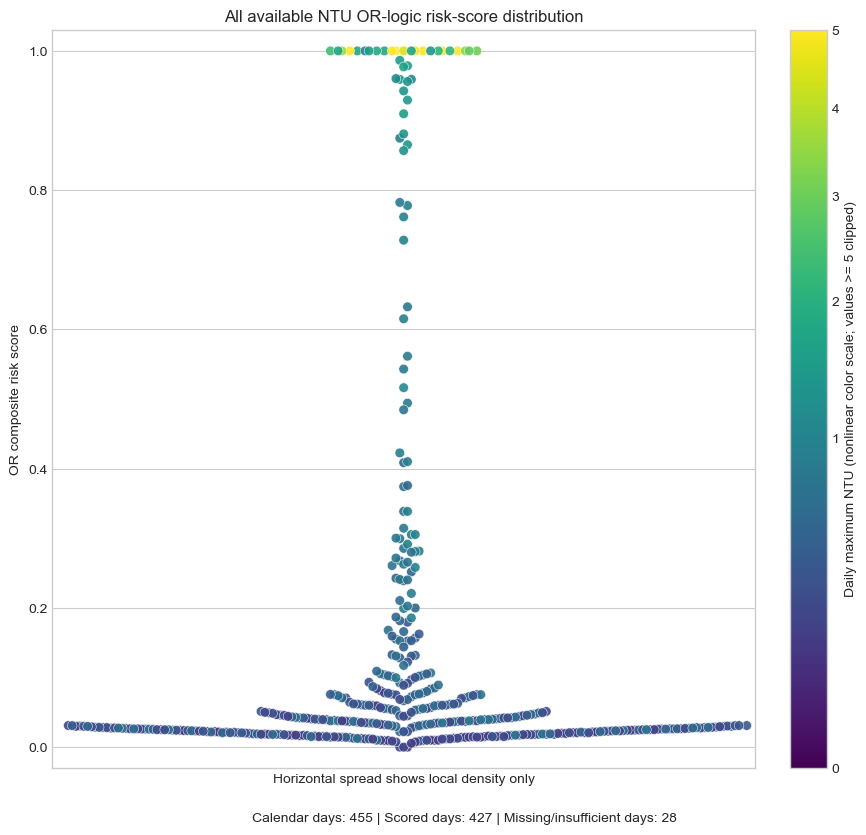

In [7]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["axes.unicode_minus"] = False

all_plot = daily_scores.dropna(subset=["OR_risk_score", "max_NTU"]).copy()

def continuous_swarm_offsets(values, y_radius=0.022, x_radius=0.055):
    # Greedy beeswarm layout: preserve y and use x only to prevent overlaps.
    values = np.asarray(values, dtype=float)
    offsets = np.zeros(len(values), dtype=float)
    placed = []
    order = np.argsort(values)
    candidates = [0.0]
    for level in range(1, len(values) + 1):
        candidates.extend([level * x_radius, -level * x_radius])

    for index in order:
        y_value = values[index]
        nearby = [
            previous_index for previous_index in placed
            if abs(values[previous_index] - y_value) < y_radius
        ]
        for candidate in candidates:
            has_overlap = False
            for previous_index in nearby:
                dx = (candidate - offsets[previous_index]) / x_radius
                dy = (y_value - values[previous_index]) / y_radius
                if dx * dx + dy * dy < 1.0:
                    has_overlap = True
                    break
            if not has_overlap:
                offsets[index] = candidate
                break
        placed.append(index)
    return offsets

all_plot["swarm_x"] = continuous_swarm_offsets(
    all_plot["OR_risk_score"].to_numpy()
)

# Use a nonlinear scale so color changes gradually slow down at higher NTU.
color_min = 0.0
color_max = 5.0
norm = mpl.colors.PowerNorm(
    gamma=0.5, vmin=color_min, vmax=color_max, clip=True
)
cmap = mpl.colormaps["viridis"]

fig, ax = plt.subplots(figsize=(9.4, 8.4))
ax.scatter(
    all_plot["swarm_x"],
    all_plot["OR_risk_score"],
    c=all_plot["max_NTU"],
    cmap=cmap,
    norm=norm,
    s=48,
    linewidth=0.4,
    edgecolor="white",
    alpha=0.90,
)

ax.set(
    xlabel="Horizontal spread shows local density only",
    ylabel="OR composite risk score",
    title="All available NTU OR-logic risk-score distribution",
)
ax.set_ylim(-0.03, 1.03)
ax.set_xticks([])
max_offset = max(abs(all_plot["swarm_x"]).max(), 0.25)
ax.set_xlim(-max_offset - 0.12, max_offset + 0.12)
ax.grid(axis="x", visible=False)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.04)
cbar.set_label("Daily maximum NTU (nonlinear color scale; values >= 5 clipped)")
cbar.set_ticks([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])

scored_days = int(daily_scores["OR_risk_score"].notna().sum())
unscored_days = int(daily_scores["OR_risk_score"].isna().sum())
fig.text(
    0.5, 0.015,
    f"Calendar days: {len(daily_scores)} | Scored days: {scored_days} | Missing/insufficient days: {unscored_days}",
    ha="center", fontsize=10
)
fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 7. 指标说明与 Excel 导出

In [8]:
indicator_definitions = pd.DataFrame([
    {
        "indicator": "max_excess",
        "definition": "max(max(NTU - 1, 0))",
        "risk_cap": RISK_CAPS["max_excess"],
        "unit": "NTU",
    },
    {
        "indicator": "exceed_ratio",
        "definition": "count(NTU > 1) / valid point count",
        "risk_cap": RISK_CAPS["exceed_ratio"],
        "unit": "proportion",
    },
    {
        "indicator": "median_excess",
        "definition": "median(NTU - 1) among NTU > 1 points; 0 when no exceedance",
        "risk_cap": RISK_CAPS["median_excess"],
        "unit": "NTU",
    },
    {
        "indicator": "ntu_std",
        "definition": "daily population standard deviation of valid NTU, ddof=0",
        "risk_cap": RISK_CAPS["ntu_std"],
        "unit": "NTU",
    },
    {
        "indicator": "longest_rising_steps",
        "definition": "longest consecutive 2-hour rising comparisons with both NTU values > 0.7",
        "risk_cap": RISK_CAPS["longest_rising_steps"],
        "unit": "steps",
    },
    {
        "indicator": "OR_risk_score",
        "definition": "1 - product(1 - r_i), with r_i = clip(indicator / risk_cap, 0, 1)",
        "risk_cap": np.nan,
        "unit": "[0, 1]",
    },
])

method_parameters = pd.DataFrame({
    "parameter": [
        "standard_limit_NTU", "warning_level_NTU", "operation_day_start",
        "operation_day_end", "expected_interval_hours",
        "expected_points_per_day", "minimum_valid_points_to_score",
        "classification_thresholds"
    ],
    "value": [
        STANDARD_LIMIT, WARNING_LEVEL, "07:00", "next day 05:00", 2,
        EXPECTED_POINTS_PER_DAY, MIN_VALID_POINTS, "Not set in this notebook"
    ]
})

with pd.ExcelWriter(EXCEL_PATH, engine="openpyxl") as writer:
    source_audit.to_excel(writer, sheet_name="source_audit", index=False)
    q1_summary.to_excel(writer, sheet_name="Q1_summary", index=False)
    daily_scores.to_excel(writer, sheet_name="all_daily_scores", index=False)
    q1.to_excel(writer, sheet_name="2026Q1_calendar", index=False)
    march.to_excel(writer, sheet_name="March_daily_scores", index=False)
    indicator_definitions.to_excel(writer, sheet_name="indicator_definitions", index=False)
    method_parameters.to_excel(writer, sheet_name="method_parameters", index=False)


def format_workbook(path):
    workbook = load_workbook(path)
    header_fill = PatternFill("solid", fgColor="1F4E78")
    header_font = Font(color="FFFFFF", bold=True)
    alternate_fill = PatternFill("solid", fgColor="DCE6F1")

    for worksheet in workbook.worksheets:
        worksheet.freeze_panes = "A2"
        worksheet.auto_filter.ref = worksheet.dimensions

        for cell in worksheet[1]:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for row_index in range(2, worksheet.max_row + 1):
            if row_index % 2 == 0:
                for cell in worksheet[row_index]:
                    cell.fill = alternate_fill

        for column_index, column_cells in enumerate(worksheet.columns, start=1):
            max_length = max(
                len(str(cell.value)) if cell.value is not None else 0
                for cell in column_cells[: min(len(column_cells), 250)]
            )
            worksheet.column_dimensions[get_column_letter(column_index)].width = min(max(max_length + 2, 11), 42)

        for row in worksheet.iter_rows(min_row=2):
            for cell in row:
                if isinstance(cell.value, pd.Timestamp):
                    cell.value = cell.value.to_pydatetime()
                if hasattr(cell.value, "year") and hasattr(cell.value, "month"):
                    cell.number_format = "yyyy-mm-dd"

    workbook.save(path)


format_workbook(EXCEL_PATH)
print("Excel 已保存：", EXCEL_PATH)
display(indicator_definitions)

Excel 已保存： /Users/jinyu/workspace/2026亚太杯/codes/p4/outputs/problem4_OR_risk_scores.xlsx


,indicator,definition,risk_cap,unit
0,max_excess,"max(max(NTU - 1, 0))",4.0000,NTU
1,exceed_ratio,count(NTU > 1) / valid point count,0.5000,proportion
2,median_excess,median(NTU - 1) among NTU > 1 points; 0 when n...,0.5000,NTU
3,ntu_std,daily population standard deviation of valid N...,0.5000,NTU
4,longest_rising_steps,longest consecutive 2-hour rising comparisons ...,4.0000,steps
5,OR_risk_score,"1 - product(1 - r_i), with r_i = clip(indicato...",NaN,"[0, 1]"


## 8. 自动验证

In [9]:
# 1) 跨午夜运行日归属与完整日点数
sample_midnight = data[data["DATETIME"].dt.hour.isin([1, 3, 5])].head(20)
assert (
    sample_midnight["OP_DATE"]
    == (sample_midnight["DATETIME"] - pd.Timedelta(days=1)).dt.normalize()
).all()
assert (daily_scores.loc[daily_scores["is_complete_day"], "n_valid"] == 12).all()

# 2) 人工序列验证连续上升、0.7 阈值和缺口重置
test_group = pd.DataFrame({
    "DATETIME": pd.to_datetime([
        "2026-01-01 07:00", "2026-01-01 09:00", "2026-01-01 11:00",
        "2026-01-01 13:00", "2026-01-01 17:00", "2026-01-01 19:00",
    ]),
    TARGET_COL: [0.71, 0.75, 0.82, np.nan, 0.90, 0.95],
})
assert longest_rising_steps(test_group) == 2

# 3) 归一化指标和 OR 评分范围
scored = daily_scores[daily_scores["can_score"]]
assert scored[NORMALIZED_INDICATORS].ge(0).all().all()
assert scored[NORMALIZED_INDICATORS].le(1).all().all()
assert scored["OR_risk_score"].between(0, 1).all()

# 4) 未超标日的前三项超标指标必须为 0
non_exceed_days = scored[scored["max_NTU"] <= STANDARD_LIMIT]
assert (non_exceed_days[["max_excess", "exceed_ratio", "median_excess"]] == 0).all().all()

# 5) 评分门槛与覆盖率
assert daily_scores.loc[daily_scores["n_valid"] < MIN_VALID_POINTS, "OR_risk_score"].isna().all()
assert daily_scores.loc[daily_scores["n_valid"] >= MIN_VALID_POINTS, "OR_risk_score"].notna().all()
assert np.allclose(
    daily_scores["data_coverage"],
    daily_scores["n_valid"] / EXPECTED_POINTS_PER_DAY,
    equal_nan=True,
)

# 6) 2026Q1 日历完整且缺失日不是零风险
assert len(q1) == 90
assert q1["OP_DATE"].nunique() == 90
assert q1.loc[q1["can_score"] != True, "OR_risk_score"].isna().all()

# 7) Excel 输出存在；蜂群图仅内嵌在 notebook 中
assert EXCEL_PATH.exists()

print("全部自动验证通过。")
print(f"2026Q1：{q1['OR_risk_score'].notna().sum()} 个可评分日，{q1['OR_risk_score'].isna().sum()} 个缺失/不足日。")

全部自动验证通过。
2026Q1：62 个可评分日，28 个缺失/不足日。


## 9. 结果使用说明

本 notebook 只给出连续 OR 风险评分，不生成风险等级或等级占比。

后续可结合蜂群图中评分密度、每日最大 NTU 的颜色变化及赛题解释需求，人工选择三个分界点，
再将评分映射为安全、低风险、中风险和高风险。分级时可额外实施“全天未超标的日期最高只判低风险”
这一业务约束，而无需修改这里的原始连续评分。

## 10. 按蜂群图界线进行四级风险分类

根据人工绘制的三条红线，结合坐标轴标定，采用以下数值界线：

| OR 综合评分 | 初始风险类型 |
|---:|---|
| \(R < 0.05\) | 安全 |
| \(0.05 <= R < 0.20\) | 低风险 |
| \(0.20 <= R < 0.99\) | 中风险 |
| \(R >= 0.99\) | 高风险 |

在初始评分分类后施加出厂水浊度硬约束：

1. 当日最大 `NTU > 1` 时，最终等级不得低于**中风险**；
2. 当日最大 `NTU < 1` 时，最终等级不得高于**低风险**；
3. 当日最大 `NTU = 1` 时不额外调整；
4. 缺失或有效点不足的日期保持未分类。

该约束只在必要时改变等级，并保留约束前后的分类结果以便审计。

In [10]:
RISK_BOUNDARIES = {
    "safe_low": 0.10,
    "low_moderate": 0.40,
    "moderate_high": 0.99,
}
RISK_LEVELS = ["安全", "低风险", "中风险", "高风险"]
RISK_ORDER_MAP = {level: index for index, level in enumerate(RISK_LEVELS)}

boundary_table = pd.DataFrame([
    {
        "risk_level": "安全",
        "OR_score_interval": "R <= 0.10",
        "lower_bound": 0.00,
        "upper_bound": 0.10,
        "lower_inclusive": True,
        "upper_inclusive": True,
    },
    {
        "risk_level": "低风险",
        "OR_score_interval": "0.10 < R <= 0.40",
        "lower_bound": 0.10,
        "upper_bound": 0.40,
        "lower_inclusive": False,
        "upper_inclusive": True,
    },
    {
        "risk_level": "中风险",
        "OR_score_interval": "0.40 < R < 0.99",
        "lower_bound": 0.40,
        "upper_bound": 0.99,
        "lower_inclusive": False,
        "upper_inclusive": False,
    },
    {
        "risk_level": "高风险",
        "OR_score_interval": "R >= 0.99",
        "lower_bound": 0.99,
        "upper_bound": 1.00,
        "lower_inclusive": True,
        "upper_inclusive": True,
    },
])

display(boundary_table)

,risk_level,OR_score_interval,lower_bound,upper_bound,lower_inclusive,upper_inclusive
0,安全,R <= 0.10,0.0000,0.1000,True,True
1,低风险,0.10 < R <= 0.40,0.1000,0.4000,False,True
2,中风险,0.40 < R < 0.99,0.4000,0.9900,False,False
3,高风险,R >= 0.99,0.9900,1.0000,True,True


### 10.1 初始分类与 NTU 硬约束

In [11]:
def classify_by_score(score):
    if pd.isna(score):
        return pd.NA
    if score <= RISK_BOUNDARIES["safe_low"]:
        return "安全"
    if score <= RISK_BOUNDARIES["low_moderate"]:
        return "低风险"
    if score < RISK_BOUNDARIES["moderate_high"]:
        return "中风险"
    return "高风险"


def apply_ntu_constraint(row):
    initial = row["initial_risk"]
    max_ntu = row["max_NTU"]

    if pd.isna(initial) or pd.isna(max_ntu):
        return initial, "未分类或无最大 NTU", False

    # NTU > 1: at least moderate risk.
    if max_ntu > STANDARD_LIMIT and RISK_ORDER_MAP[initial] < RISK_ORDER_MAP["中风险"]:
        return "中风险", "max_NTU > 1，强制不低于中风险", True

    # NTU < 1: at most low risk.
    if max_ntu < STANDARD_LIMIT and RISK_ORDER_MAP[initial] > RISK_ORDER_MAP["低风险"]:
        return "低风险", "max_NTU < 1，强制不高于低风险", True

    return initial, "未触发约束", False


classified_daily = daily_scores.copy()
classified_daily["initial_risk"] = classified_daily["OR_risk_score"].map(
    classify_by_score
)

constraint_result = classified_daily.apply(
    apply_ntu_constraint, axis=1, result_type="expand"
)
classified_daily["final_risk"] = constraint_result[0]
classified_daily["constraint_reason"] = constraint_result[1]
classified_daily["changed_by_constraint"] = constraint_result[2].fillna(False).astype(bool)

classified_daily["classification_change"] = np.where(
    classified_daily["changed_by_constraint"],
    classified_daily["initial_risk"].astype(str)
    + " -> "
    + classified_daily["final_risk"].astype(str),
    "未改变",
)

display(
    classified_daily.loc[
        classified_daily["OR_risk_score"].notna(),
        [
            "OP_DATE", "OR_risk_score", "max_NTU", "initial_risk",
            "final_risk", "changed_by_constraint", "constraint_reason"
        ],
    ].head(20)
)

,OP_DATE,OR_risk_score,max_NTU,initial_risk,final_risk,changed_by_constraint,constraint_reason
0,2025-01-01,0.0099,0.1200,安全,安全,False,未触发约束
1,2025-01-02,0.0197,0.1300,安全,安全,False,未触发约束
2,2025-01-03,0.0144,0.1300,安全,安全,False,未触发约束
3,2025-01-04,0.0224,0.1500,安全,安全,False,未触发约束
4,2025-01-05,0.0141,0.1300,安全,安全,False,未触发约束
5,2025-01-06,0.0166,0.1300,安全,安全,False,未触发约束
6,2025-01-07,0.0223,0.1500,安全,安全,False,未触发约束
7,2025-01-08,0.0200,0.1400,安全,安全,False,未触发约束
8,2025-01-09,0.0399,0.2000,安全,安全,False,未触发约束
9,2025-01-10,0.0407,0.1900,安全,安全,False,未触发约束


### 10.2 全历史分类统计

In [12]:
scored_classified = classified_daily.dropna(
    subset=["OR_risk_score", "initial_risk", "final_risk"]
).copy()

initial_counts = (
    scored_classified["initial_risk"]
    .value_counts()
    .reindex(RISK_LEVELS, fill_value=0)
)
final_counts = (
    scored_classified["final_risk"]
    .value_counts()
    .reindex(RISK_LEVELS, fill_value=0)
)

classification_summary = pd.DataFrame({
    "risk_level": RISK_LEVELS,
    "initial_days": [int(initial_counts[level]) for level in RISK_LEVELS],
    "initial_share": [
        initial_counts[level] / len(scored_classified) for level in RISK_LEVELS
    ],
    "final_days": [int(final_counts[level]) for level in RISK_LEVELS],
    "final_share": [
        final_counts[level] / len(scored_classified) for level in RISK_LEVELS
    ],
})
classification_summary["day_change"] = (
    classification_summary["final_days"]
    - classification_summary["initial_days"]
)

constraint_summary = pd.DataFrame({
    "item": [
        "全历史日历日",
        "可评分并分类日",
        "缺失或有效点不足日",
        "因 NTU 硬约束改变分类的日期数",
        "改变分类占可分类日比例",
        "max_NTU > 1 导致上调的日期数",
        "max_NTU < 1 导致下调的日期数",
    ],
    "value": [
        len(classified_daily),
        len(scored_classified),
        classified_daily["OR_risk_score"].isna().sum(),
        scored_classified["changed_by_constraint"].sum(),
        scored_classified["changed_by_constraint"].mean(),
        (
            scored_classified["changed_by_constraint"]
            & scored_classified["max_NTU"].gt(STANDARD_LIMIT)
        ).sum(),
        (
            scored_classified["changed_by_constraint"]
            & scored_classified["max_NTU"].lt(STANDARD_LIMIT)
        ).sum(),
    ],
})

change_direction = (
    scored_classified.loc[scored_classified["changed_by_constraint"]]
    .groupby(
        ["initial_risk", "final_risk", "constraint_reason"],
        dropna=False,
    )
    .size()
    .rename("days")
    .reset_index()
    .sort_values("days", ascending=False)
)

display(classification_summary)
display(constraint_summary)
display(change_direction)

,risk_level,initial_days,initial_share,final_days,final_share,day_change
0,安全,315,0.7377,315,0.7377,0
1,低风险,61,0.1429,76,0.1780,15
2,中风险,28,0.0656,14,0.0328,-14
3,高风险,23,0.0539,22,0.0515,-1


,item,value
0,全历史日历日,455.0000
1,可评分并分类日,427.0000
2,缺失或有效点不足日,28.0000
3,因 NTU 硬约束改变分类的日期数,15.0000
4,改变分类占可分类日比例,0.0351
5,max_NTU > 1 导致上调的日期数,0.0000
6,max_NTU < 1 导致下调的日期数,15.0000


,initial_risk,final_risk,constraint_reason,days
0,中风险,低风险,max_NTU < 1，强制不高于低风险,14
1,高风险,低风险,max_NTU < 1，强制不高于低风险,1


### 10.3 因硬约束改变分类的具体日期

In [13]:
constraint_changed_days = (
    scored_classified.loc[
        scored_classified["changed_by_constraint"],
        [
            "OP_DATE", "OR_risk_score", "max_NTU", "mean_NTU",
            *RAW_INDICATORS, *NORMALIZED_INDICATORS,
            "initial_risk", "final_risk", "classification_change",
            "constraint_reason", "n_valid", "data_coverage",
        ],
    ]
    .sort_values(["OP_DATE"])
    .reset_index(drop=True)
)

display(constraint_changed_days)
print(
    f"共 {len(constraint_changed_days)} 个点因 NTU 硬约束改变分类。"
)

,OP_DATE,OR_risk_score,max_NTU,mean_NTU,max_excess,exceed_ratio,median_excess,ntu_std,longest_rising_steps,r_max_excess,r_exceed_ratio,r_median_excess,r_ntu_std,r_longest_rising_steps,initial_risk,final_risk,classification_change,constraint_reason,n_valid,data_coverage
0,2025-01-29,0.5615,0.8500,0.5300,0.0000,0.0000,0.0000,0.2076,1.0000,0.0000,0.0000,0.0000,0.4153,0.2500,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
1,2025-02-05,0.8746,0.9100,0.6325,0.0000,0.0000,0.0000,0.2493,3.0000,0.0000,0.0000,0.0000,0.4985,0.7500,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
2,2025-02-16,0.4086,0.5400,0.2767,0.0000,0.0000,0.0000,0.2043,0.0000,0.0000,0.0000,0.0000,0.4086,0.0000,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
3,2025-03-23,0.6152,0.8900,0.4508,0.0000,0.0000,0.0000,0.2435,1.0000,0.0000,0.0000,0.0000,0.4870,0.2500,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
4,2025-05-10,0.4941,0.8700,0.4358,0.0000,0.0000,0.0000,0.2471,0.0000,0.0000,0.0000,0.0000,0.4941,0.0000,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
5,2025-08-02,0.4845,0.7500,0.3633,0.0000,0.0000,0.0000,0.2423,0.0000,0.0000,0.0000,0.0000,0.4845,0.0000,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
6,2025-09-06,0.7282,0.9900,0.6092,0.0000,0.0000,0.0000,0.2282,2.0000,0.0000,0.0000,0.0000,0.4563,0.5000,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
7,2025-10-02,0.6324,0.7900,0.5542,0.0000,0.0000,0.0000,0.1324,2.0000,0.0000,0.0000,0.0000,0.2649,0.5000,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
8,2025-10-27,0.4226,0.8800,0.7508,0.0000,0.0000,0.0000,0.1151,1.0000,0.0000,0.0000,0.0000,0.2301,0.2500,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
9,2025-11-19,0.4101,0.9200,0.6142,0.0000,0.0000,0.0000,0.1067,1.0000,0.0000,0.0000,0.0000,0.2135,0.2500,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000


共 15 个点因 NTU 硬约束改变分类。


### 10.4 2026 年第一季度与 3 月统计

In [14]:
q1_classified = classified_daily[
    classified_daily["OP_DATE"].between(Q1_START, Q1_END)
].copy()
march_classified = classified_daily[
    classified_daily["OP_DATE"].between(MARCH_START, MARCH_END)
].copy()

def summarize_period(frame, period_name):
    valid = frame.dropna(subset=["final_risk"])
    counts = valid["final_risk"].value_counts().reindex(RISK_LEVELS, fill_value=0)
    result = pd.DataFrame({
        "period": period_name,
        "risk_level": RISK_LEVELS,
        "days": [int(counts[level]) for level in RISK_LEVELS],
        "share_among_classified_days": [
            counts[level] / len(valid) if len(valid) else np.nan
            for level in RISK_LEVELS
        ],
    })
    result["classified_days"] = len(valid)
    result["unclassified_days"] = len(frame) - len(valid)
    result["constraint_changed_days"] = int(
        valid["changed_by_constraint"].sum()
    )
    return result

period_summary = pd.concat([
    summarize_period(q1_classified, "2026Q1"),
    summarize_period(march_classified, "2026-03"),
], ignore_index=True)

march_classification = march_classified[[
    "OP_DATE", "n_valid", "data_status", "mean_NTU", "max_NTU",
    "OR_risk_score", "initial_risk", "final_risk",
    "changed_by_constraint", "constraint_reason",
]].copy()

display(period_summary)
display(march_classification)

,period,risk_level,days,share_among_classified_days,classified_days,unclassified_days,constraint_changed_days
0,2026Q1,安全,50,0.8065,62,28,0
1,2026Q1,低风险,8,0.1290,62,28,0
2,2026Q1,中风险,1,0.0161,62,28,0
3,2026Q1,高风险,3,0.0484,62,28,0
4,2026-03,安全,25,0.8065,31,0,0
5,2026-03,低风险,4,0.1290,31,0,0
6,2026-03,中风险,1,0.0323,31,0,0
7,2026-03,高风险,1,0.0323,31,0,0


,OP_DATE,n_valid,data_status,mean_NTU,max_NTU,OR_risk_score,initial_risk,final_risk,changed_by_constraint,constraint_reason
424,2026-03-01,12,完整可评分,0.4525,0.4800,0.0318,安全,安全,False,未触发约束
425,2026-03-02,12,完整可评分,0.4733,0.4900,0.0298,安全,安全,False,未触发约束
426,2026-03-03,12,完整可评分,0.4933,0.5100,0.0275,安全,安全,False,未触发约束
427,2026-03-04,12,完整可评分,0.5017,0.5200,0.0325,安全,安全,False,未触发约束
428,2026-03-05,12,完整可评分,0.5308,0.5600,0.0331,安全,安全,False,未触发约束
429,2026-03-06,12,完整可评分,0.5400,0.5600,0.0183,安全,安全,False,未触发约束
430,2026-03-07,12,完整可评分,0.5250,0.5400,0.0224,安全,安全,False,未触发约束
431,2026-03-08,12,完整可评分,0.5367,0.5600,0.0275,安全,安全,False,未触发约束
432,2026-03-09,12,完整可评分,0.5442,0.5600,0.0191,安全,安全,False,未触发约束
433,2026-03-10,12,完整可评分,0.5392,0.5500,0.0152,安全,安全,False,未触发约束


### 10.5 将分类结果追加到原 Excel 工作簿

In [15]:
with pd.ExcelWriter(
    EXCEL_PATH, engine="openpyxl", mode="a", if_sheet_exists="replace"
) as writer:
    boundary_table.to_excel(
        writer, sheet_name="risk_boundaries", index=False
    )
    classified_daily.to_excel(
        writer, sheet_name="all_risk_classification", index=False
    )
    classification_summary.to_excel(
        writer, sheet_name="classification_summary", index=False
    )
    constraint_summary.to_excel(
        writer, sheet_name="constraint_summary", index=False
    )
    constraint_changed_days.to_excel(
        writer, sheet_name="constraint_changed_days", index=False
    )
    period_summary.to_excel(
        writer, sheet_name="period_risk_summary", index=False
    )
    march_classification.to_excel(
        writer, sheet_name="March_classification", index=False
    )

format_workbook(EXCEL_PATH)

assert classified_daily.loc[
    classified_daily["max_NTU"].gt(STANDARD_LIMIT)
    & classified_daily["final_risk"].notna(),
    "final_risk",
].map(RISK_ORDER_MAP).ge(RISK_ORDER_MAP["中风险"]).all()

assert classified_daily.loc[
    classified_daily["max_NTU"].lt(STANDARD_LIMIT)
    & classified_daily["final_risk"].notna(),
    "final_risk",
].map(RISK_ORDER_MAP).le(RISK_ORDER_MAP["低风险"]).all()

print("风险分类与硬约束验证通过。")
print("分类结果已追加至：", EXCEL_PATH)

风险分类与硬约束验证通过。
分类结果已追加至： /Users/jinyu/workspace/2026亚太杯/codes/p4/outputs/problem4_OR_risk_scores.xlsx
